This .ipynb notebook serves as a simple inference demo for BIM-JEPA-finetuned-ifcnetcore

HF link: https://huggingface.co/llama2thedog/BIM-JEPA-hf

We inference it on some IFCNetCore test samples

You can also run this same demo with the BIM-JEPA-FM checkpoint, which was fine-tuned from an encoder pre-trained on over 2.1 million BIM elements (vs ~900k for the one above). The two models are architecturally identical, so only the checkpoint path changes:

```python
from huggingface_hub import hf_hub_download
hf_hub_download(
    "llama2thedog/BIM-JEPA-FM-hf",
    "checkpoints/bim-jepa-fm-ifcnetcore.ckpt",
    local_dir="/content/",
)
```

Then set `CKPT_PATH = "/content/checkpoints/bim-jepa-fm-ifcnetcore.ckpt"` in the setup cell below.

Please use T4 GPU! (Runtime --> Change runtime type --> Select T4 GPU --> Connect)

In [3]:
%%capture
# takes about 4 minutes to install the packages
!pip uninstall -y torch torchvision torchaudio xformers
!pip install --index-url https://download.pytorch.org/whl/cu121 torch==2.4.1 torchvision==0.19.1
!pip install -q pytorch-lightning==2.5.3 torchmetrics
# installation for pytorch3d below will take about 40 minutes, but i have already downloaded it onto HF
# so simply just download the whl from the HF!
# !pip install "git+https://github.com/facebookresearch/pytorch3d.git" (slow!)
!pip install https://huggingface.co/llama2thedog/BIM-JEPA-hf/resolve/main/pytorch3d-0.7.9-cp312-cp312-linux_x86_64.whl

In [2]:
import os
import sys
import glob
import zipfile
from huggingface_hub import snapshot_download

HF_REPO_ID = "llama2thedog/BIM-JEPA-hf"

print("Downloading BIM-JEPA code, checkpoints, point clouds, and meshes from HuggingFace...")

# 1. Pull the whole repo into /content/
snapshot_download(
    repo_id=HF_REPO_ID,
    local_dir="/content/",
)

# 2. Unzip every archive that came down (point clouds + meshes)
for zp in sorted(glob.glob("/content/*.zip")):
    print(f"Unzipping {os.path.basename(zp)}...")
    with zipfile.ZipFile(zp, "r") as z:
        z.extractall("/content/")
print("Unzip complete!")

# 3. Configure paths now that everything is in place
REPO_ROOT = "/content"
CKPT_PATH = "/content/checkpoints/epoch=349-step=60550.ckpt"
DATA_DIR  = "/content/processed_IFCNetCore_pointclouds_4096_test"   # point clouds (.npy)
MESH_DIR  = "/content/IFCNetCore_meshes_test"                       # original meshes (.obj) for better visualization of element

# Tell python to look for the codebase in REPO_ROOT
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

print("\n✅ All paths configured!")
print("   DATA_DIR:", DATA_DIR)
print("   MESH_DIR:", MESH_DIR)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 40 files:   0%|          | 0/40 [00:00<?, ?it/s]

Unzipping IFCNetCore_meshes_test.zip...
Unzipping processed_IFCNetCore_pointclouds_4096_test.zip...
Unzip complete!

✅ All paths configured!
   DATA_DIR: /content/processed_IFCNetCore_pointclouds_4096_test
   MESH_DIR: /content/IFCNetCore_meshes_test


In [4]:
# @title
import re
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass
print("Device:", device)

from bimjepa.models.classification import BimJepaClassification
from bimjepa.utils.checkpoint import extract_model_checkpoint
from bimjepa.datasets.ifcnet_datamodule import IFCNetCoreDataModule

# 1) Instantiate the module (no setup call!)
model = BimJepaClassification()

# 2) Read the raw checkpoint state_dict
sd = extract_model_checkpoint(CKPT_PATH)

# 3) Infer num_classes and head style from checkpoint
def infer_head_info(state):
    if "cls_head.weight" in state and state["cls_head.weight"].ndim == 2:
        return state["cls_head.weight"].shape[0], "linear"
    last_idx, last_shape = -1, None
    for k, v in state.items():
        m = re.match(r"^cls_head\.(\d+)\.weight$", k)
        if m:
            i = int(m.group(1))
            if i > last_idx:
                last_idx, last_shape = i, v.shape
    if last_shape is not None:
        return last_shape[0], "mlp"
    return 20, "linear"

NUM_CLASSES, HEAD_TYPE = infer_head_info(sd)
print(f"Inferred head: {HEAD_TYPE}, num_classes={NUM_CLASSES}")

# 4) Build a head that matches the checkpoint
if HEAD_TYPE == "mlp":
    model.cls_head = nn.Sequential(
        nn.Linear(model.first_cls_head_dim, model.hparams.cls_head_dim * 2, bias=False),
        nn.BatchNorm1d(model.hparams.cls_head_dim * 2),
        nn.ReLU(),
        nn.Dropout(model.hparams.cls_head_dropout),
        nn.Linear(model.hparams.cls_head_dim * 2, model.hparams.cls_head_dim, bias=False),
        nn.BatchNorm1d(model.hparams.cls_head_dim),
        nn.ReLU(),
        nn.Dropout(model.hparams.cls_head_dropout),
        nn.Linear(model.hparams.cls_head_dim, NUM_CLASSES),
    )
else:
    model.cls_head = nn.Linear(model.first_cls_head_dim, NUM_CLASSES)

# 5) Load ALL weights
missing, unexpected = model.load_state_dict(sd, strict=False)
print("Missing keys (first 10):", [k for k in missing if k.startswith("cls_head.")][:10])
print("Unexpected (first 10):", unexpected[:10])

# 6) Move to device AFTER the head exists
model.to(device).eval()
print("cls_head device:", next(model.cls_head.parameters()).device)

# 7) Prepare the datamodule mappings
dm = IFCNetCoreDataModule(
    data_dir=DATA_DIR,
    batch_size=1,
    num_workers=0,
    val_split_ratio=0.0,
    seed=42,
)

for stage in ["fit","validate","test","predict"]:
    try: dm.setup(stage)
    except Exception: pass

class_to_idx = getattr(dm, "class_to_idx", {})
idx_to_class = {v:k for k,v in class_to_idx.items()}
print("Num classes detected on disk:", len(idx_to_class))

Device: cuda


/content/bimjepa/utils/checkpoint.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path, map_location="cuda:0")


Inferred head: mlp, num_classes=20
Missing keys (first 10): []
Unexpected (first 10): []
cls_head device: cuda:0
IFCNetCoreDataModule setup complete:
 - Found 20 classes.
 - Train samples: 0
 - Validation samples: 0
 - Test samples: 2379
IFCNetCoreDataModule setup complete:
 - Found 20 classes.
 - Train samples: 0
 - Validation samples: 0
 - Test samples: 2379
IFCNetCoreDataModule setup complete:
 - Found 20 classes.
 - Train samples: 0
 - Validation samples: 0
 - Test samples: 2379
IFCNetCoreDataModule setup complete:
 - Found 20 classes.
 - Train samples: 0
 - Validation samples: 0
 - Test samples: 2379
Num classes detected on disk: 20


Visualization code

In [5]:
# @title
import os

def predict_file(path: str):
    if not os.path.isfile(path):
        raise FileNotFoundError(path)
    arr = np.load(path)
    if arr.ndim != 2 or arr.shape[1] < 3:
        raise ValueError(f"Expected (N, >=3) array, got {arr.shape}")
    pts_xyz = arr[:, :3].astype(np.float32)
    pts = torch.from_numpy(pts_xyz).unsqueeze(0).to(device)
    with torch.no_grad():
        if hasattr(model, "val_transformations"):
            pts = model.val_transformations(pts)
        logits = model(pts)
        probs = F.softmax(logits, dim=-1)[0].cpu()
        pred_idx = int(torch.argmax(probs).item())
        pred_name = idx_to_class.get(pred_idx, f"class_{pred_idx}")
        pred_prob = float(probs[pred_idx].item())
    return pred_idx, pred_name, pred_prob

def _actual_from_path(path: str, data_root: str) -> str:
    rel = os.path.relpath(path, data_root)
    return rel.split(os.sep)[0]

This cell below randomly visualize 5 files in 'processed_IFCNetCore_pointclouds_4096_test'

Indexed 2379 mesh file(s) under /content/IFCNetCore_meshes_test
Selected 5 point-cloud file(s):
  - /content/processed_IFCNetCore_pointclouds_4096_test/IfcSanitaryTerminal/test/7fb5611fc9aa404bba619ccacb7dd876.npy
  - /content/processed_IFCNetCore_pointclouds_4096_test/IfcRailing/test/1c29a80f054b47a3a9ede1f6054700be.npy
  - /content/processed_IFCNetCore_pointclouds_4096_test/IfcLamp/test/19f0c1f7a8ea40e5bac9625d3cdf8770.npy
  - /content/processed_IFCNetCore_pointclouds_4096_test/IfcCableCarrierFitting/test/dbaf94cbc44845edb5fd58579e176046.npy
  - /content/processed_IFCNetCore_pointclouds_4096_test/IfcWall/test/17bfc3a3b58d4466894f23b26c2f1ad0.npy

[1] 7fb5611fc9aa404bba619ccacb7dd876.npy


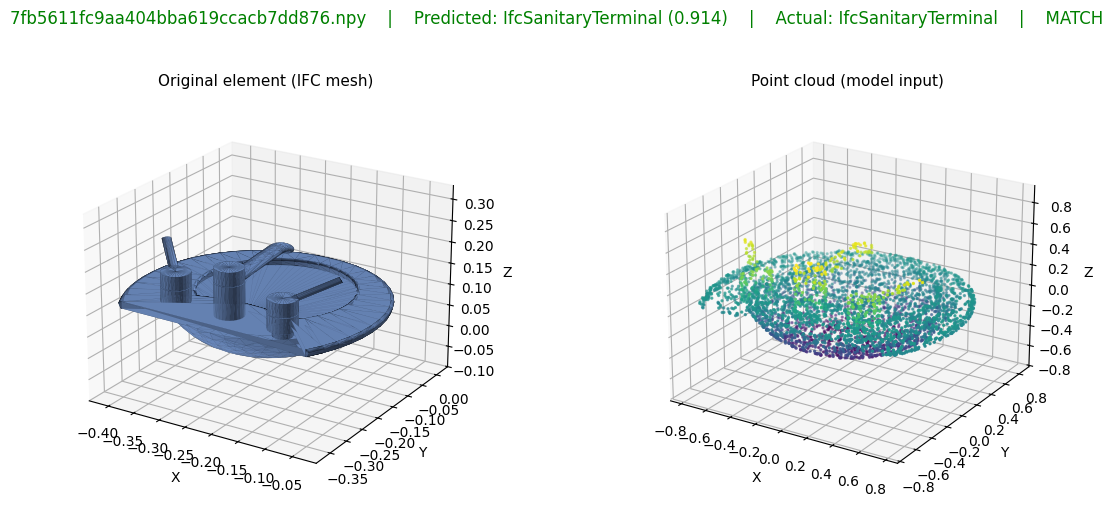


[2] 1c29a80f054b47a3a9ede1f6054700be.npy


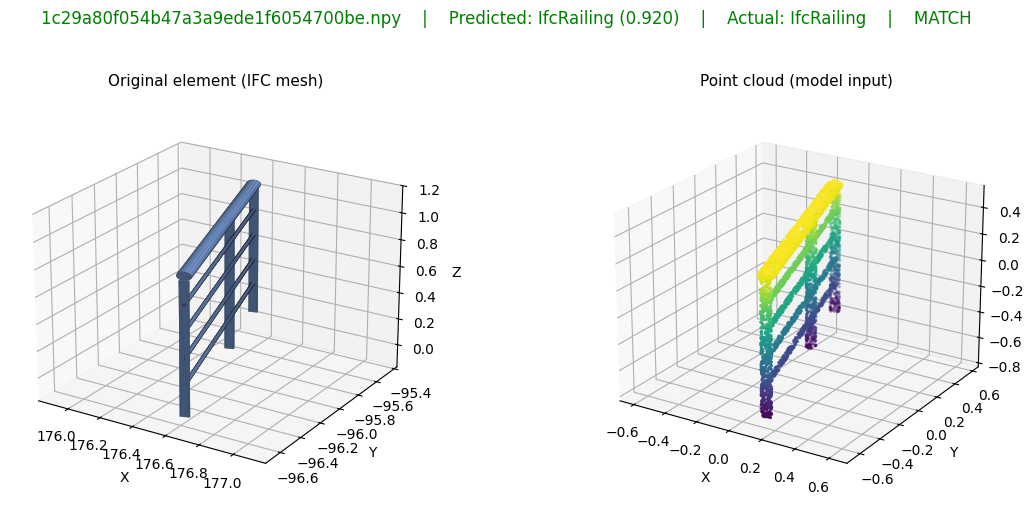


[3] 19f0c1f7a8ea40e5bac9625d3cdf8770.npy


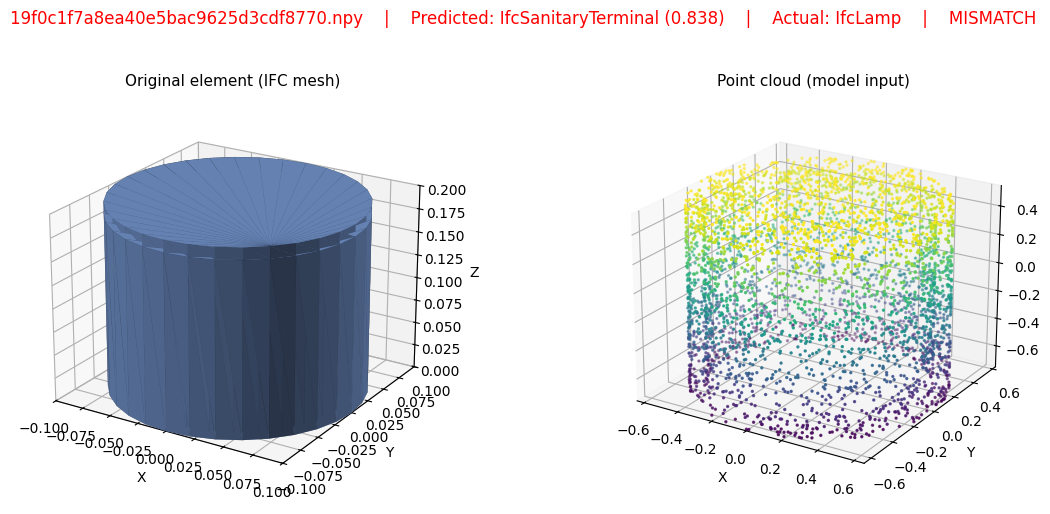


[4] dbaf94cbc44845edb5fd58579e176046.npy


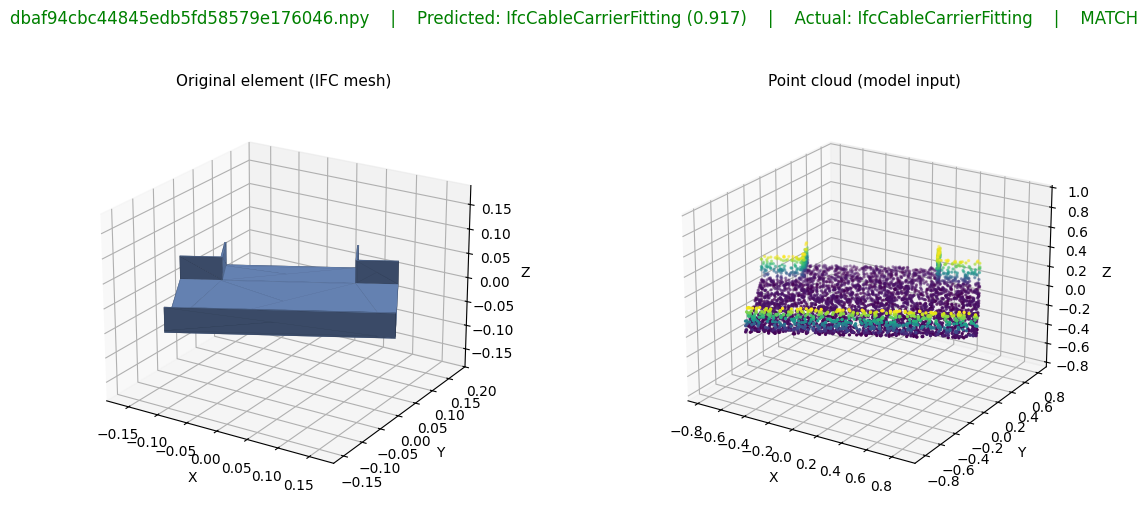


[5] 17bfc3a3b58d4466894f23b26c2f1ad0.npy


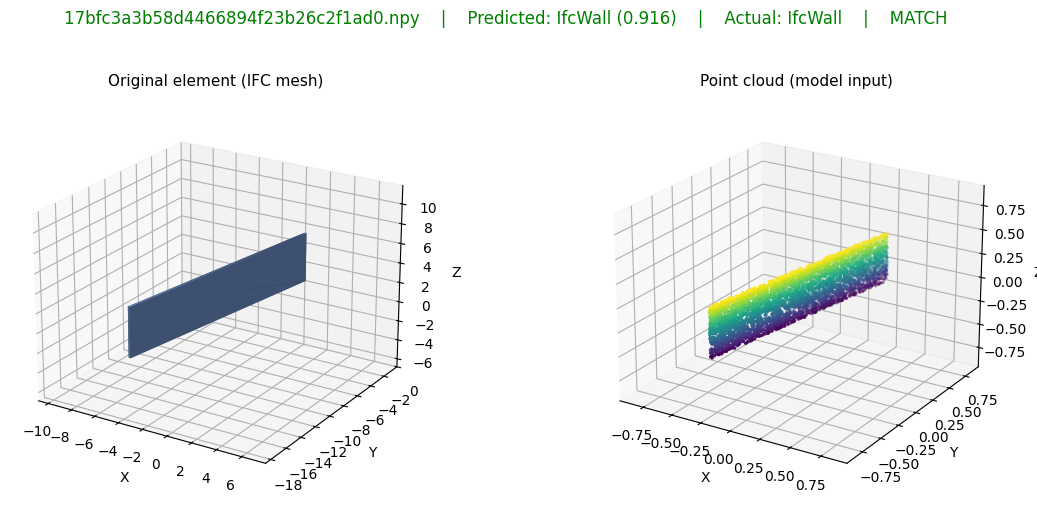

In [15]:
# @title
# --- Side-by-side: ORIGINAL mesh (left) vs POINT CLOUD (right) ------------
import os, glob, random
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# ----------------------------- CONFIG ------------------------------------
N_SAMPLES = 5                 # CHANGE THIS TO VIEW MORE OR LESS
RANDOM_PICK = True            # True -> random pick (not folder order)
STRATIFIED_PER_CLASS = False  # True -> at most one file per class first
SEED = None                   # set an int for reproducible picks
VIEW = dict(elev=22, azim=-58)   # camera applied to both panels
# -------------------------------------------------------------------------

# trimesh, for loading the .obj meshes
try:
    import trimesh
except ImportError:
    !pip install -q trimesh
    import trimesh

# meshes were already downloaded + unzipped in the 2nd cell
MESH_DIR = globals().get("MESH_DIR", "/content/IFCNetCore_meshes_test")

# ---------------------------- mesh matching ------------------------------
MESH_EXTS = (".obj", ".ply", ".stl", ".off")

def _norm(s):                      # tolerate a trailing "_" on either side
    return s.rstrip("_")

def _build_mesh_index(roots):
    index = {}
    for root in roots:
        if not root or not os.path.isdir(root):
            continue
        for ext in MESH_EXTS:
            for p in glob.glob(os.path.join(root, "**", f"*{ext}"), recursive=True):
                stem = os.path.splitext(os.path.basename(p))[0]
                for key in {stem, _norm(stem)}:
                    index.setdefault(key, []).append(p)
    return index

def _find_mesh_for(npy_path, mesh_index):
    stem = os.path.splitext(os.path.basename(npy_path))[0]
    cls = _actual_from_path(npy_path, DATA_DIR)          # from your earlier cell
    for key in (stem, _norm(stem)):
        cands = mesh_index.get(key)
        if cands:
            for c in cands:
                if f"{os.sep}{cls}{os.sep}" in c:        # disambiguate by class
                    return c
            return cands[0]
    return None

# ---------------------------- rendering ----------------------------------
_BASE  = np.array([0.45, 0.58, 0.80])                    # steel blue
_LIGHT = np.array([0.4, 0.5, 0.85]); _LIGHT = _LIGHT / np.linalg.norm(_LIGHT)

def _eq_aspect(ax, P):
    mn, mx = P.min(0), P.max(0)
    c = (mn + mx) / 2
    r = (mx - mn).max() / 2 or 1.0
    ax.set_xlim(c[0]-r, c[0]+r); ax.set_ylim(c[1]-r, c[1]+r); ax.set_zlim(c[2]-r, c[2]+r)

def _draw_mesh(ax, path):
    m = trimesh.load(path, force="mesh")
    V = np.asarray(m.vertices, float); Fc = np.asarray(m.faces)
    if len(Fc) == 0:
        raise ValueError("mesh has no faces")
    v0, v1, v2 = V[Fc[:, 0]], V[Fc[:, 1]], V[Fc[:, 2]]
    n = np.cross(v1 - v0, v2 - v0)
    ln = np.linalg.norm(n, axis=1, keepdims=True); ln[ln == 0] = 1
    shade = 0.35 + 0.65 * np.clip(np.abs((n / ln) @ _LIGHT), 0, 1)
    coll = Poly3DCollection(V[Fc], linewidths=0.15)
    coll.set_facecolor(np.clip(shade[:, None] * _BASE[None, :], 0, 1))
    coll.set_edgecolor((0, 0, 0, 0.18))
    ax.add_collection3d(coll); _eq_aspect(ax, V)

def _draw_cloud(ax, P):
    ax.scatter(P[:, 0], P[:, 1], P[:, 2], s=2, c=P[:, 2], cmap="viridis")
    _eq_aspect(ax, P)

def visualize_mesh_vs_pointcloud(path, data_root, mesh_index):
    arr = np.load(path)
    if arr.ndim != 2 or arr.shape[1] < 3:
        raise ValueError(f"Expected (N,>=3) array, got {arr.shape}")
    pts = arr[:, :3].astype(np.float32)

    pred_idx, pred_name, pred_prob = predict_file(path)  # from your earlier cell
    actual_name = _actual_from_path(path, data_root)
    correct = (pred_name == actual_name)

    fig = plt.figure(figsize=(12, 5.2))
    axL = fig.add_subplot(1, 2, 1, projection="3d")
    axR = fig.add_subplot(1, 2, 2, projection="3d")

    mp = _find_mesh_for(path, mesh_index)
    if mp is not None:
        try:
            _draw_mesh(axL, mp)
            axL.set_title("Original element (IFC mesh)", fontsize=11)
        except Exception as e:
            _draw_cloud(axL, pts); axL.set_title(f"mesh load failed: {e}", fontsize=9)
    else:
        _draw_cloud(axL, pts)
        axL.set_title("Original mesh not found for this file", fontsize=10)

    _draw_cloud(axR, pts)
    axR.set_title("Point cloud (model input)", fontsize=11)

    for a in (axL, axR):
        a.set_xlabel("X"); a.set_ylabel("Y"); a.set_zlabel("Z")
        a.view_init(**VIEW)

    fig.suptitle(
        f"{os.path.basename(path)}    |    Predicted: {pred_name} ({pred_prob:.3f})"
        f"    |    Actual: {actual_name}    |    {'MATCH' if correct else 'MISMATCH'}",
        color=("green" if correct else "red"), fontsize=12,
    )
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# --------------------- pick files (your existing logic) ------------------
if SEED is not None:
    random.seed(SEED)

found = sorted(glob.glob(os.path.join(DATA_DIR, "**", "*.npy"), recursive=True))
if not found:
    raise RuntimeError("No .npy files found under DATA_DIR.")

def _class_of(path, root):
    return os.path.relpath(path, root).split(os.sep)[0]

SAMPLE_FILES = []
if STRATIFIED_PER_CLASS:
    from collections import defaultdict
    by_class = defaultdict(list)
    for p in found:
        by_class[_class_of(p, DATA_DIR)].append(p)
    classes = list(by_class.keys()); random.shuffle(classes)
    for cls in classes:
        if len(SAMPLE_FILES) >= N_SAMPLES:
            break
        SAMPLE_FILES.append(random.choice(by_class[cls]))
    if len(SAMPLE_FILES) < N_SAMPLES:
        remaining = [p for p in found if p not in set(SAMPLE_FILES)]
        SAMPLE_FILES += (random.sample(remaining, k=min(N_SAMPLES - len(SAMPLE_FILES), len(remaining)))
                         if RANDOM_PICK else remaining[:max(0, N_SAMPLES - len(SAMPLE_FILES))])
else:
    SAMPLE_FILES = (random.sample(found, k=min(N_SAMPLES, len(found)))
                    if RANDOM_PICK else found[:min(N_SAMPLES, len(found))])

# build the mesh lookup once
mesh_index = _build_mesh_index([MESH_DIR])
n_indexed = len({p for v in mesh_index.values() for p in v})
print(f"Indexed {n_indexed} mesh file(s) under {MESH_DIR}")
print(f"Selected {len(SAMPLE_FILES)} point-cloud file(s):")
for p in SAMPLE_FILES:
    print("  -", p)

for i, p in enumerate(SAMPLE_FILES, 1):
    print(f"\n[{i}] {os.path.basename(p)}")
    try:
        visualize_mesh_vs_pointcloud(p, DATA_DIR, mesh_index)
    except Exception as e:
        print("ERROR:", e)